# Explorar o explotar: el dilema de los bandidos

**Facsímil 10 · Aprendizaje por refuerzo** — capítulo 3 (exploración, *bandits* y validación de
políticas).

Este es el dilema más puro del aprendizaje por interacción, y aparece en cualquier sistema que aprende
mientras actúa: tests A/B, recomendaciones, anuncios, dosis de un tratamiento. Tienes varias opciones
(máquinas, versiones de una web, tratamientos) y no sabes cuál es mejor. Cada prueba te da información,
pero también te cuesta. ¿Sigues con la que parece buena (**explotar**) o arriesgas con otras por si son
mejores (**explorar**)? En este cuaderno mides, en *regret* (lo que pierdes frente a haber jugado
perfecto), tres estrategias clásicas, y ves por qué explorar **con criterio** bate a explorar al azar.

### Qué vas a aprender
- El dilema **explorar vs explotar** y por qué los dos extremos son malos.
- Tres estrategias: **ε-greedy**, **UCB** y **Thompson sampling**, y la intuición de cada una.
- Qué es el **regret** y por qué es la métrica honesta (no «cuánto gané», sino «cuánto dejé de ganar»).
- A *ver* la diferencia en la **curva de regret**: las buenas estrategias frenan; el azar no.

### Cuánto cuesta
Unos 12 minutos. CPU, sin claves.


> **Inteligencia artificial para gente curiosa** · facsímil interactivo
> 
> Web del facsímil: https://www.iaparagentecuriosa.686f6c61.dev/ · Autor: @686f6c61 · Fecha: 2026-06-26 · Versión 1.0
> 
> Este cuaderno acompaña al facsímil: ejecútalo de arriba abajo, lee cada celda de texto
> antes de correr la de código y detente en las salidas. La gracia no es que «salga», sino
> entender *por qué* sale.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(1)

# 6 maquinas con probabilidad de premio desconocida. La 4 es la mejor (0.75).
PROBS = np.array([0.20, 0.45, 0.55, 0.40, 0.75, 0.30])
MEJOR = PROBS.max()
N = 2000          # tiradas totales
def tira(brazo): return 1.0 if np.random.random() < PROBS[brazo] else 0.0
print(f"{len(PROBS)} maquinas. La mejor da premio el {MEJOR*100:.0f}% (pero el agente NO lo sabe).")
print("El agente solo puede aprender tirando y mirando que sale.")


6 maquinas. La mejor da premio el 75% (pero el agente NO lo sabe).
El agente solo puede aprender tirando y mirando que sale.


## 1. El dilema, y por qué los extremos son malos

Imagina que solo **explotas**: tiras siempre de la primera máquina que te dio un premio. Quizá te
anclaste en una mediocre y nunca descubres la buena. Ahora imagina que solo **exploras**: tiras siempre
al azar para «aprender», sin aprovechar nunca lo aprendido. Malgastas. La gracia está en el equilibrio:
explorar **lo justo** para descubrir cuál es la buena, y luego explotarla. Las tres estrategias que
veremos son tres formas distintas de lograr ese equilibrio.


## 2. Tres formas de decidir

- **ε-greedy:** casi siempre tira de la mejor conocida; con probabilidad pequeña ε, tira al azar (explora
  a ciegas). Simple, pero explora para siempre con la misma intensidad.
- **UCB1** (*upper confidence bound*): elige la de mayor «valor estimado **+** bono de incertidumbre».
  Explora lo que ha probado poco, de forma dirigida. Optimismo ante la incertidumbre.
- **Thompson sampling:** mantiene una creencia (una distribución *beta*) por máquina y muestrea de ella;
  explora de forma bayesiana y elegante, proporcional a la probabilidad de que cada una sea la mejor.


In [2]:
def correr(politica):
    q = np.zeros(len(PROBS)); n = np.zeros(len(PROBS)); recompensa = 0.0; curva = []
    a_beta = np.ones(len(PROBS)); b_beta = np.ones(len(PROBS))   # para Thompson
    for t in range(1, N+1):
        if politica == "aleatorio":
            brazo = np.random.randint(len(PROBS))
        elif politica == "epsilon":
            brazo = np.random.randint(len(PROBS)) if np.random.random() < 0.1 else int(np.argmax(q))
        elif politica == "ucb":
            bono = np.sqrt(2*np.log(t) / np.maximum(n, 1e-9))
            brazo = int(np.argmax(q + bono)) if t > len(PROBS) else (t-1)
        else:  # thompson
            brazo = int(np.argmax(np.random.beta(a_beta, b_beta)))
        r = tira(brazo)
        n[brazo] += 1; q[brazo] += (r - q[brazo]) / n[brazo]
        a_beta[brazo] += r; b_beta[brazo] += (1-r); recompensa += r
        curva.append(t*MEJOR - recompensa)   # regret acumulado hasta t
    return recompensa, curva

resultados = {pol: correr(pol) for pol in ["aleatorio", "epsilon", "ucb", "thompson"]}
print(f"{'estrategia':<12}{'premios':>9}{'regret final':>14}")
for pol, (rec, curva) in resultados.items():
    print(f"{pol:<12}{rec:>9.0f}{curva[-1]:>14.1f}")


estrategia    premios  regret final
aleatorio         892         608.0
epsilon          1437          63.0
ucb              1386         114.0
thompson         1455          45.0


## 3. El regret, la métrica honesta

El **regret** es lo que dejas de ganar frente a un oráculo que **siempre** juega la mejor máquina:
cuanto **más bajo, mejor**. No mide «cuánto gané» (que depende de la suerte), sino «cuánto perdí por no
saber desde el principio cuál era la buena». El aleatorio acumula muchísimo (no aprende: tira a ciegas
para siempre). Las otras tres lo dejan muy atrás porque **descubren** la buena y se quedan con ella.
Aquí Thompson suele ser el más afinado; ε-greedy le sigue de cerca; UCB explora con más ganas al
principio, así que su regret tarda un poco más en frenarse.


## 4. Verlo: la curva de regret

La diferencia se *ve* en cómo crece el regret con el tiempo. Una estrategia que aprende hace que su
curva se **aplane** (deja de acumular regret porque ya explota la buena). La aleatoria crece en línea
recta para siempre. Esa curvatura **es** el aprendizaje.


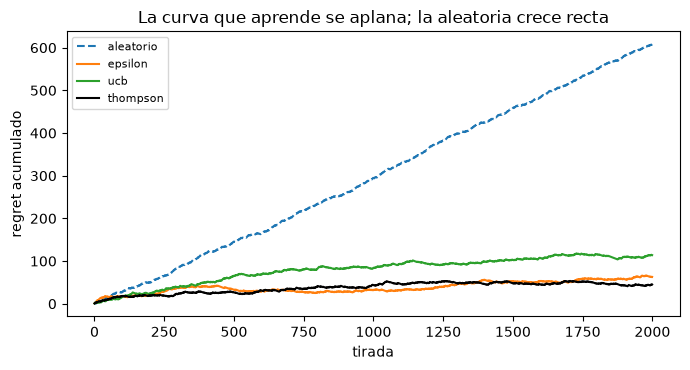

Fijate: las estrategias listas frenan (aprenden cual es la buena); la aleatoria, nunca.


In [3]:
plt.figure(figsize=(7, 3.8))
for pol, (rec, curva) in resultados.items():
    estilo = "--" if pol == "aleatorio" else "-"
    plt.plot(curva, estilo, label=pol, color="black" if pol=="thompson" else None)
plt.xlabel("tirada"); plt.ylabel("regret acumulado")
plt.title("La curva que aprende se aplana; la aleatoria crece recta")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()
print("Fijate: las estrategias listas frenan (aprenden cual es la buena); la aleatoria, nunca.")


## 5. Pruébalo tú

1. **Sube ε a 0,5** en `epsilon`: explora la mitad del tiempo. ¿Mejora o empeora el regret? Demasiada
   exploración también se paga.
2. **Acerca las máquinas** (todas entre 0,5 y 0,55): cuando las opciones se parecen, distinguir la buena
   cuesta mucho más y todas las estrategias sufren.
3. **Alarga el horizonte** a `N = 20000`: ¿se nota más la ventaja de UCB y Thompson a largo plazo? Sus
   garantías teóricas son asintóticas.
4. **Bandits no estacionarios:** haz que la mejor máquina cambie a mitad de partida. ¿Qué estrategia se
   adapta mejor? (Pista: la que sigue explorando un poco.)


## 6. Errores comunes

- **Explotar demasiado pronto.** Si te quedas con la primera que parece buena, puedes anclarte en una
  mediocre. Hay que explorar lo justo primero.
- **Explorar para siempre con la misma intensidad** (ε-greedy con ε fijo y alto): malgastas tiradas en
  máquinas que ya sabes que son malas.
- **Mirar «cuánto gané» en vez del regret.** Lo que ganaste depende de la suerte; el regret mide tu
  decisión frente a lo óptimo.
- **Asumir que el mundo no cambia.** Muchos problemas reales son no estacionarios: la mejor opción de hoy
  puede no serlo mañana.


## 7. Qué te llevas

- El dilema **explorar/explotar** aparece siempre que aprendes mientras actúas: cada decisión es a la vez
  una apuesta y un experimento.
- Estrategias como **UCB** y **Thompson** baten de calle al azar porque exploran **de forma dirigida**
  (prueban lo incierto, no lo aleatorio); Thompson suele afinar más que ε-greedy.
- El **regret** es la métrica honesta: no «cuánto gané», sino «cuánto dejé de ganar frente a lo óptimo».
  Su curva, al aplanarse, es la imagen del aprendizaje.

**Para seguir:** los *bandits* son el RL más simple (un solo paso). El facsímil escala esto a secuencias
de decisiones (MDP, el cuaderno anterior) y a aprender de preferencias humanas (RLHF, capítulo 5).


---

### Ficha del cuaderno

- **Obra:** *Inteligencia artificial para gente curiosa* (facsímil interactivo).
- **Web:** https://www.iaparagentecuriosa.686f6c61.dev/
- **Autor:** @686f6c61
- **Fecha:** 2026-06-26
- **Versión:** 1.0

*Material pedagógico. Las salidas que ves son reales: se generan al ejecutar el código, no están escritas a mano. Si cambias algo, cambiarán: esa es la idea.*